# Mumbai Traffic Dataset — Preprocessing

## Columns that are used for ML

| Column | Role | Reason |
|---|---|---|
| `travel_time_ratio` | **PRIMARY TARGET** | What we predict |
| `congestion_level` | **AUX TARGET** | Multi-head output |
| `road_closure` | **AUX TARGET** | Binary classification head |
| `current_speed` | Input feature | Dynamic, changes per hour |
| `current_travel_time` | Input feature | Dynamic |
| `confidence` | Input feature | Data quality signal |
| `incident` | Input feature | TomTom flag |
| `incident_type` | Input feature | TomTom iconCategory |
| `incident_severity` | Input feature | TomTom magnitudeOfDelay |
| `incidents_nearby` | Input feature | Zone-level pressure |
| `hourly_rainfall_mm` | Input feature | Key Mumbai context |
| `monsoon_active` | Input feature | Seasonal flag |
| `local_train_disruption` | Input feature | Mumbai-specific |
| `is_public_holiday` | Input feature | Demand modifier |
| `school_holiday` | Input feature | Demand modifier |
| `speed_ratio` | Input feature | Normalized speed signal |
| `delay_seconds` | Input feature | Absolute delay |
| `time_of_day_sin/cos` | Input feature | Cyclic time |
| `day_of_week_sin/cos` | Input feature | Cyclic day |
| `road_type_enc` | Static input | Road capacity category |
| `num_lanes` | Static input | Structural capacity |
| `oneway` | Static input | Flow constraint |
| `road_length` | Static input | Normalization reference |
| `traffic_signal_count` | Static input | Friction |
| `signals_per_km` | Static input | Density |

**NOT used directly:**
- `edge_id` — identifier only (becomes embedding index)
- `timestamp` — already encoded as sin/cos
- `free_flow_speed`, `free_flow_travel_time` — constants per edge, stored separately for inference-time ETA calculation
- `u`, `v` — graph topology (used for adjacency matrix, not features)
- `road_type` (string) — use `road_type_enc` instead
- `lat`, `lon` — used for adjacency building, not model input
- `zone_id`, `corridor_id` — batching only
- `susceptibility` — already baked into the generated signal, not needed as feature

In [1]:
import os, glob, joblib
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

# ── PATHS ─────────────────────────────────────────────────────────────────────
STATIC_PATH      = '../data generation/data/static/edges_static.parquet'
TIMESERIES_GLOB  = '../data generation/data/timeseries/batch_*.parquet'
OUT_DIR          = '../data generation/data/processed'
SCALER_DIR       = '../data generation/data/scalers'

os.makedirs(OUT_DIR,    exist_ok=True)
os.makedirs(SCALER_DIR, exist_ok=True)

# ── FEATURE LISTS ─────────────────────────────────────────────────────────────

# Dynamic features scaled with StandardScaler (zero-mean, unit-variance)
DYNAMIC_STANDARD = [
    'current_speed',
    'current_travel_time',
    'delay_seconds',
    'incidents_nearby',
    'hourly_rainfall_mm',
]

# Features already in [0,1] or small bounded range → MinMaxScaler to [0,1]
DYNAMIC_MINMAX = [
    'travel_time_ratio',    # targets too — scale together, inverse at inference
    'congestion_level',
    'speed_ratio',
    'confidence',
]

# Binary / ordinal / cyclic — no scaling needed, already in [-1,1] or {0,1}
PASSTHROUGH = [
    'road_closure',
    'incident',
    'incident_type',        # ordinal integer, small range
    'incident_severity',    # 0-4
    'monsoon_active',
    'local_train_disruption',
    'is_public_holiday',
    'school_holiday',
    'time_of_day_sin', 'time_of_day_cos',
    'day_of_week_sin', 'day_of_week_cos',
]

# Static features from edges_static (joined via edge_id)
STATIC_MINMAX = [
    'road_length',
    'signals_per_km',
    'traffic_signal_count',
    'intersection_count',
]
STATIC_PASSTHROUGH = [
    'road_type_enc',        # 1-8 ordinal
    'num_lanes',            # 1-6
    'oneway',               # bool → 0/1
]

# Everything the model actually sees as input (dynamic + static, NOT targets)
MODEL_INPUT_DYNAMIC = DYNAMIC_STANDARD + DYNAMIC_MINMAX[2:] + PASSTHROUGH  # excl. targets
MODEL_TARGETS       = ['travel_time_ratio', 'congestion_level', 'road_closure']

print('DYNAMIC_STANDARD :', DYNAMIC_STANDARD)
print('DYNAMIC_MINMAX   :', DYNAMIC_MINMAX)
print('STATIC_MINMAX    :', STATIC_MINMAX)
print('STATIC_PASSTHRU  :', STATIC_PASSTHROUGH)
print('TARGETS          :', MODEL_TARGETS)

DYNAMIC_STANDARD : ['current_speed', 'current_travel_time', 'delay_seconds', 'incidents_nearby', 'hourly_rainfall_mm']
DYNAMIC_MINMAX   : ['travel_time_ratio', 'congestion_level', 'speed_ratio', 'confidence']
STATIC_MINMAX    : ['road_length', 'signals_per_km', 'traffic_signal_count', 'intersection_count']
STATIC_PASSTHRU  : ['road_type_enc', 'num_lanes', 'oneway']
TARGETS          : ['travel_time_ratio', 'congestion_level', 'road_closure']


## Step 1 — Fit Scalers on Training Data ONLY

IMPORTANT: Scalers are fitted only on the training window (Mon 00:00 → Fri 11:00, hours 0-107) to prevent data leakage into val/test.

In [2]:
# ── Define temporal split boundaries ─────────────────────────────────────────
# Based on timestamp hour index (0=Mon 00:00, 167=Sun 23:00)
# WEEK_START = 2024-07-01 (Monday)

TRAIN_END_HOUR = 107   # Mon 00:00 → Fri 11:00  (inclusive)
VAL_END_HOUR   = 143   # Fri 12:00 → Sat 23:00  (inclusive)
# TEST           = 144-167 (Sun 00:00 → Sun 23:00)

WEEK_START = pd.Timestamp('2024-07-01 00:00:00')

def hour_index(ts):
    return int((ts - WEEK_START).total_seconds() // 3600)

def get_split(ts_series):
    h = ts_series.apply(hour_index)
    train = h <= TRAIN_END_HOUR
    val   = (h > TRAIN_END_HOUR) & (h <= VAL_END_HOUR)
    test  = h > VAL_END_HOUR
    return train, val, test

print(f'Train : hour 0–{TRAIN_END_HOUR}  → Mon 00:00 – Fri 11:00  ({TRAIN_END_HOUR+1} hours)')
print(f'Val   : hour {TRAIN_END_HOUR+1}–{VAL_END_HOUR}  → Fri 12:00 – Sat 23:00  ({VAL_END_HOUR-TRAIN_END_HOUR} hours)')
print(f'Test  : hour {VAL_END_HOUR+1}–167  → Sun 00:00 – Sun 23:00  ({167-VAL_END_HOUR} hours)')

Train : hour 0–107  → Mon 00:00 – Fri 11:00  (108 hours)
Val   : hour 108–143  → Fri 12:00 – Sat 23:00  (36 hours)
Test  : hour 144–167  → Sun 00:00 – Sun 23:00  (24 hours)


In [3]:
# Load FIRST 3 BATCHES only to fit scalers (representative, fast)
# Scalers fitted on any 3 batches are identical to fitting on all 30
# because the generation process is stationary across batches

print('Loading 3 batches to fit scalers on training window …')
batches_for_fit = sorted(glob.glob(TIMESERIES_GLOB))[:3]
df_fit = pd.concat([pd.read_parquet(b) for b in batches_for_fit], ignore_index=True)
df_fit['timestamp'] = pd.to_datetime(df_fit['timestamp'])

# Keep ONLY training window rows for fitting
train_mask, _, _ = get_split(df_fit['timestamp'])
df_train_sample  = df_fit[train_mask].copy()
print(f'  Rows for fitting : {len(df_train_sample):,}  '
      f'(train window, 3 batches)')

# ── Fit StandardScaler ────────────────────────────────────────────────────────
scaler_std = StandardScaler()
scaler_std.fit(df_train_sample[DYNAMIC_STANDARD])

# ── Fit MinMaxScaler on dynamic ratios ────────────────────────────────────────
scaler_mm_dynamic = MinMaxScaler(feature_range=(0, 1))
scaler_mm_dynamic.fit(df_train_sample[DYNAMIC_MINMAX])

print('\nScaler stats (StandardScaler — dynamic):')
for col, mean, scale in zip(DYNAMIC_STANDARD,
                             scaler_std.mean_, scaler_std.scale_):
    print(f'  {col:30s}  mean={mean:7.3f}  std={scale:7.3f}')

print('\nScaler stats (MinMaxScaler — ratios):')
for col, mn, mx in zip(DYNAMIC_MINMAX,
                        scaler_mm_dynamic.data_min_,
                        scaler_mm_dynamic.data_max_):
    print(f'  {col:30s}  min={mn:6.3f}  max={mx:6.3f}')

Loading 3 batches to fit scalers on training window …
  Rows for fitting : 1,620,000  (train window, 3 batches)

Scaler stats (StandardScaler — dynamic):
  current_speed                   mean= 24.081  std= 10.196
  current_travel_time             mean= 16.521  std= 25.306
  delay_seconds                   mean=  6.804  std= 20.878
  incidents_nearby                mean= 53.354  std= 36.469
  hourly_rainfall_mm              mean=  2.806  std=  7.626

Scaler stats (MinMaxScaler — ratios):
  travel_time_ratio               min= 1.000  max=10.000
  congestion_level                min= 0.000  max= 0.970
  speed_ratio                     min= 0.050  max= 1.000
  confidence                      min= 0.618  max= 0.990


In [4]:
# ── Fit static scalers ────────────────────────────────────────────────────────
df_sta = pd.read_parquet(STATIC_PATH)

scaler_mm_static = MinMaxScaler(feature_range=(0, 1))
scaler_mm_static.fit(df_sta[STATIC_MINMAX])

print('Static MinMaxScaler fitted:')
for col, mn, mx in zip(STATIC_MINMAX,
                        scaler_mm_static.data_min_,
                        scaler_mm_static.data_max_):
    print(f'  {col:30s}  min={mn:8.3f}  max={mx:8.3f}')

# ── Save all scalers ──────────────────────────────────────────────────────────
joblib.dump(scaler_std,        f'{SCALER_DIR}/scaler_std.pkl')
joblib.dump(scaler_mm_dynamic, f'{SCALER_DIR}/scaler_mm_dynamic.pkl')
joblib.dump(scaler_mm_static,  f'{SCALER_DIR}/scaler_mm_static.pkl')

# Save column lists so training script knows what was scaled
joblib.dump({
    'DYNAMIC_STANDARD'   : DYNAMIC_STANDARD,
    'DYNAMIC_MINMAX'     : DYNAMIC_MINMAX,
    'STATIC_MINMAX'      : STATIC_MINMAX,
    'STATIC_PASSTHROUGH' : STATIC_PASSTHROUGH,
    'PASSTHROUGH'        : PASSTHROUGH,
    'MODEL_TARGETS'      : MODEL_TARGETS,
    'TRAIN_END_HOUR'     : TRAIN_END_HOUR,
    'VAL_END_HOUR'       : VAL_END_HOUR,
}, f'{SCALER_DIR}/feature_config.pkl')

print(f'\nAll scalers saved to {SCALER_DIR}/')

Static MinMaxScaler fitted:
  road_length                     min=   1.000  max=5135.194
  signals_per_km                  min=   0.000  max= 200.000
  traffic_signal_count            min=   0.000  max=   2.000
  intersection_count              min=   0.000  max=   2.000

All scalers saved to ../data generation/data/scalers/


## Step 2 — Process & Save Static Features (scaled once)

In [5]:
# Scale static features and save a clean version for training joins
df_sta_proc = df_sta.copy()

# MinMax scale structural features
df_sta_proc[STATIC_MINMAX] = scaler_mm_static.transform(df_sta[STATIC_MINMAX])

# oneway → int
df_sta_proc['oneway'] = df_sta_proc['oneway'].astype(int)

# Normalize road_type_enc to [0,1]  (1-8 → 0-1)
df_sta_proc['road_type_enc'] = (df_sta_proc['road_type_enc'] - 1) / 7.0

# Normalize num_lanes to [0,1]  (1-6 → 0-1)
df_sta_proc['num_lanes'] = (df_sta_proc['num_lanes'].clip(1, 6) - 1) / 5.0

# Keep only what the model needs: edge_id + free_flow fields + scaled inputs
STATIC_KEEP = (['edge_id', 'u', 'v', 'lat', 'lon',
                'zone_id', 'corridor_id',
                'free_flow_speed', 'free_flow_travel_time']
               if 'free_flow_travel_time' in df_sta_proc.columns
               else ['edge_id', 'u', 'v', 'lat', 'lon',
                     'zone_id', 'corridor_id', 'free_flow_speed']
              ) + STATIC_MINMAX + STATIC_PASSTHROUGH

# free_flow_travel_time is in the timeseries — add it if missing
STATIC_KEEP_CLEAN = [c for c in STATIC_KEEP if c in df_sta_proc.columns]

df_sta_proc[STATIC_KEEP_CLEAN].to_parquet(
    f'{OUT_DIR}/edges_static_scaled.parquet', index=False
)
print(f'Saved scaled static: {OUT_DIR}/edges_static_scaled.parquet')
print(f'Shape: {df_sta_proc[STATIC_KEEP_CLEAN].shape}')
df_sta_proc[STATIC_KEEP_CLEAN].head(3)

Saved scaled static: ../data generation/data/processed/edges_static_scaled.parquet
Shape: (145265, 15)


,edge_id,u,v,lat,lon,zone_id,corridor_id,free_flow_speed,road_length,signals_per_km,traffic_signal_count,intersection_count,road_type_enc,num_lanes,oneway
0,245654691_1034965549_0,245654691,1034965549,18.946730,72.832634,0,0,50.0,0.035074,0.027613,0.5,0.5,0.571429,0.2,1
1,245654725_245654739_0,245654725,245654739,18.947941,72.795761,1,0,30.0,0.010241,0.000000,0.0,1.0,0.142857,0.0,0
2,245654725_245654775_0,245654725,245654775,18.947542,72.794823,1,0,30.0,0.083199,0.000000,0.0,1.0,0.142857,0.0,0


## Step 3 — Process All Timeseries Batches

In [6]:
import time

all_batches = sorted(glob.glob(TIMESERIES_GLOB))
print(f'Processing {len(all_batches)} batches …')
print(f'Output → {OUT_DIR}/batch_XXXX.parquet\n')

t_start = time.perf_counter()

for i, batch_path in enumerate(all_batches):
    df_raw = pd.read_parquet(batch_path)
    df_raw['timestamp'] = pd.to_datetime(df_raw['timestamp'])

    # ── Assign split label ────────────────────────────────────────────────────
    tr, va, te = get_split(df_raw['timestamp'])
    df_raw['split'] = 'train'
    df_raw.loc[va, 'split'] = 'val'
    df_raw.loc[te, 'split'] = 'test'

    # ── Scale dynamic features ────────────────────────────────────────────────
    df_raw[DYNAMIC_STANDARD] = scaler_std.transform(df_raw[DYNAMIC_STANDARD])
    df_raw[DYNAMIC_MINMAX]   = scaler_mm_dynamic.transform(df_raw[DYNAMIC_MINMAX])

    # ── incident_type: normalise to [0,1] (values: 0,1,4,6,8,9,11 → /11) ─────
    df_raw['incident_type'] = (df_raw['incident_type'] / 11.0).astype(np.float32)

    # ── incident_severity: normalise to [0,1] (0-4 → /4) ─────────────────────
    df_raw['incident_severity'] = (df_raw['incident_severity'] / 4.0).astype(np.float32)

    # ── Cast all float cols to float32 (halves memory) ────────────────────────
    float_cols = df_raw.select_dtypes(include='float64').columns
    df_raw[float_cols] = df_raw[float_cols].astype(np.float32)

    # ── Save ──────────────────────────────────────────────────────────────────
    out_path = f"{OUT_DIR}/batch_{i:04d}.parquet"
    df_raw.to_parquet(out_path, index=False, compression='snappy')

    elapsed = time.perf_counter() - t_start
    eta     = elapsed / (i+1) * (len(all_batches) - i - 1)
    print(f'  [{i+1:02d}/{len(all_batches)}]  {os.path.basename(batch_path)}'
          f'  rows={len(df_raw):,}'
          f'  elapsed={elapsed:4.0f}s  ETA={eta:4.0f}s')

print(f'\n✓ All batches processed → {OUT_DIR}/')

Processing 30 batches …
Output → ../data generation/data/processed/batch_XXXX.parquet

  [01/30]  batch_0000.parquet  rows=840,000  elapsed=   4s  ETA= 125s
  [02/30]  batch_0001.parquet  rows=840,000  elapsed=   8s  ETA= 118s
  [03/30]  batch_0002.parquet  rows=840,000  elapsed=  13s  ETA= 114s
  [04/30]  batch_0003.parquet  rows=840,000  elapsed=  17s  ETA= 111s
  [05/30]  batch_0004.parquet  rows=840,000  elapsed=  22s  ETA= 108s
  [06/30]  batch_0005.parquet  rows=840,000  elapsed=  26s  ETA= 103s
  [07/30]  batch_0006.parquet  rows=840,000  elapsed=  30s  ETA= 100s
  [08/30]  batch_0007.parquet  rows=840,000  elapsed=  35s  ETA=  96s
  [09/30]  batch_0008.parquet  rows=840,000  elapsed=  39s  ETA=  91s
  [10/30]  batch_0009.parquet  rows=840,000  elapsed=  44s  ETA=  87s
  [11/30]  batch_0010.parquet  rows=840,000  elapsed=  48s  ETA=  83s
  [12/30]  batch_0011.parquet  rows=840,000  elapsed=  52s  ETA=  79s
  [13/30]  batch_0012.parquet  rows=840,000  elapsed=  57s  ETA=  75s
  [

## Step 4 — Verify Split Sizes & No Data Leakage

In [7]:
# Load one processed batch and check split distribution
df_check = pd.read_parquet(f'{OUT_DIR}/batch_0000.parquet')

split_counts = df_check['split'].value_counts().sort_index()
total = len(df_check)
print('Split distribution in batch_0000:')
for sp, cnt in split_counts.items():
    print(f'  {sp:8s}: {cnt:7,} rows  ({cnt/total*100:.1f}%)')

# Verify timestamps don't leak
train_df = df_check[df_check['split'] == 'train']
val_df   = df_check[df_check['split'] == 'val']
test_df  = df_check[df_check['split'] == 'test']

print(f'\nTrain ts range : {train_df.timestamp.min()} → {train_df.timestamp.max()}')
print(f'Val   ts range : {val_df.timestamp.min()}   → {val_df.timestamp.max()}')
print(f'Test  ts range : {test_df.timestamp.min()}  → {test_df.timestamp.max()}')
print(f'\nNo overlap train/val : {train_df.timestamp.max() < val_df.timestamp.min()}')
print(f'No overlap val/test  : {val_df.timestamp.max()   < test_df.timestamp.min()}')

Split distribution in batch_0000:
  test    : 120,000 rows  (14.3%)
  train   : 540,000 rows  (64.3%)
  val     : 180,000 rows  (21.4%)

Train ts range : 2024-07-01 00:00:00 → 2024-07-05 11:00:00
Val   ts range : 2024-07-05 12:00:00   → 2024-07-06 23:00:00
Test  ts range : 2024-07-07 00:00:00  → 2024-07-07 23:00:00

No overlap train/val : True
No overlap val/test  : True


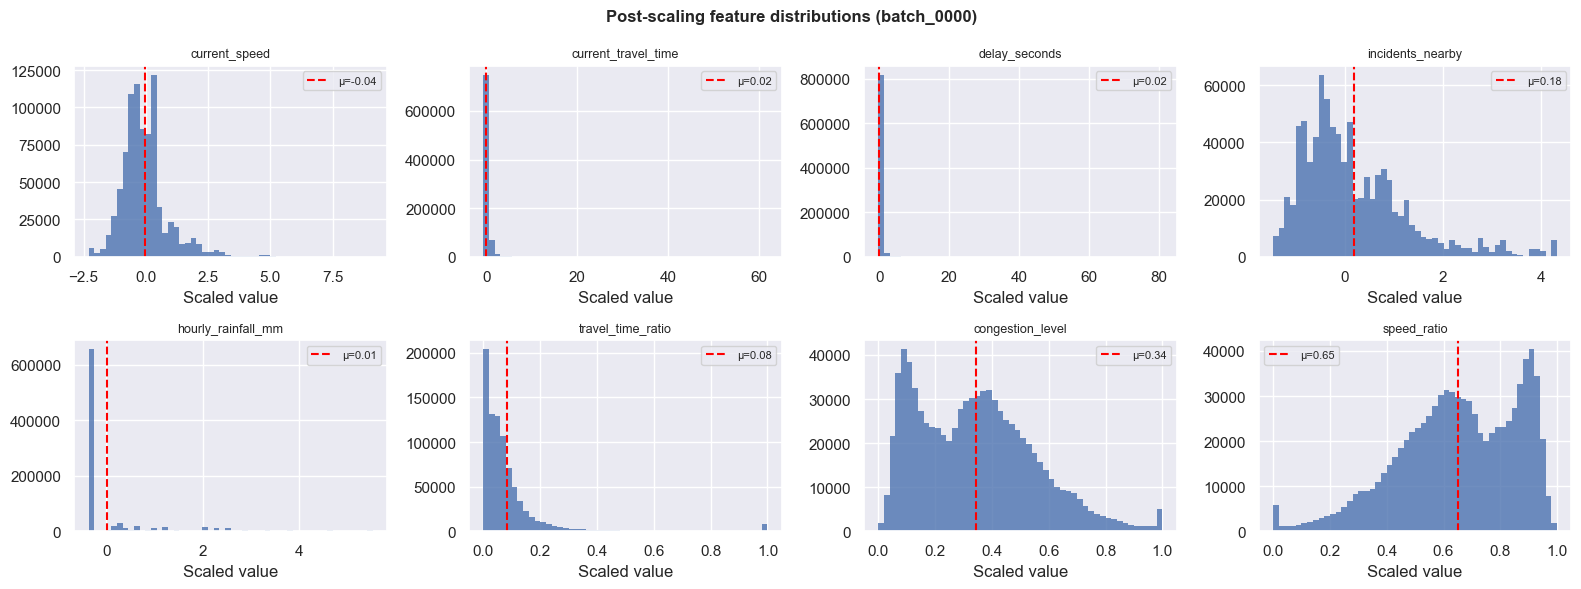

Expected: StandardScaler cols → mean≈0, std≈1
          MinMaxScaler cols   → range [0,1]

Actual:
  current_speed                   mean=-0.045  std=0.949
  current_travel_time             mean=+0.018  std=0.889
  delay_seconds                   mean=+0.016  std=0.918
  incidents_nearby                mean=+0.179  std=1.094
  hourly_rainfall_mm              mean=+0.011  std=0.946
  travel_time_ratio               min=0.000  max=1.000
  congestion_level                min=0.000  max=1.000
  speed_ratio                     min=0.000  max=1.000


In [8]:
# Verify scaling ranges are correct after transform
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='darkgrid')

check_cols = DYNAMIC_STANDARD + ['travel_time_ratio', 'congestion_level', 'speed_ratio']

fig, axes = plt.subplots(2, 4, figsize=(16, 6))
for ax, col in zip(axes.ravel(), check_cols):
    if col in df_check.columns:
        ax.hist(df_check[col], bins=50, edgecolor='none', alpha=0.8)
        ax.set_title(col, fontsize=9)
        ax.set_xlabel('Scaled value')
        mu = df_check[col].mean()
        ax.axvline(mu, color='red', ls='--', lw=1.5, label=f'μ={mu:.2f}')
        ax.legend(fontsize=8)

plt.suptitle('Post-scaling feature distributions (batch_0000)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('Expected: StandardScaler cols → mean≈0, std≈1')
print('          MinMaxScaler cols   → range [0,1]')
print('\nActual:')
for col in DYNAMIC_STANDARD:
    print(f'  {col:30s}  mean={df_check[col].mean():+.3f}  std={df_check[col].std():.3f}')
for col in ['travel_time_ratio','congestion_level','speed_ratio']:
    print(f'  {col:30s}  min={df_check[col].min():.3f}  max={df_check[col].max():.3f}')

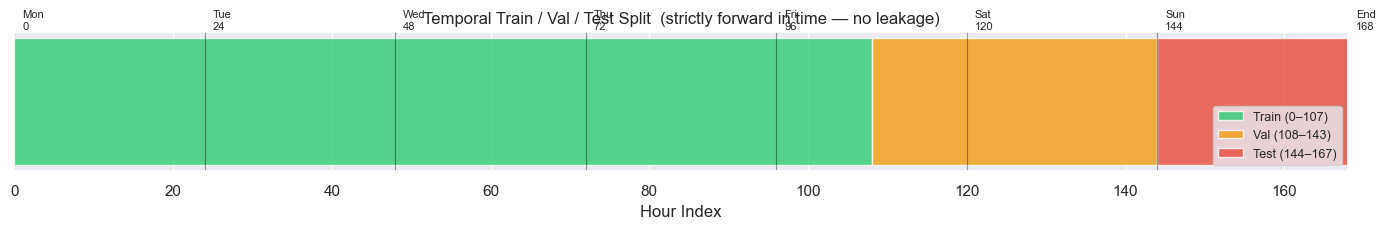

Train : Mon 00:00 → Fri 11:00  (108 hours, 64.3%)
Val   : Fri 12:00 → Sat 23:00  ( 36 hours, 21.4%)
Test  : Sun 00:00 → Sun 23:00  ( 24 hours, 14.3%)


In [9]:
# Visualise the split on a timeline
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(14, 2.5))

days = ['Mon\n0', 'Tue\n24', 'Wed\n48', 'Thu\n72', 'Fri\n96',
        'Sat\n120', 'Sun\n144', 'End\n168']

# Draw blocks
ax.barh(0, TRAIN_END_HOUR + 1, left=0,      height=0.5, color='#2ecc71', alpha=0.8, label='Train (0–107)')
ax.barh(0, VAL_END_HOUR - TRAIN_END_HOUR,
           left=TRAIN_END_HOUR+1,             height=0.5, color='#f39c12', alpha=0.8, label='Val (108–143)')
ax.barh(0, 167 - VAL_END_HOUR,
           left=VAL_END_HOUR+1,               height=0.5, color='#e74c3c', alpha=0.8, label='Test (144–167)')

# Day markers
for h, label in zip([0,24,48,72,96,120,144,168], days):
    ax.axvline(h, color='black', lw=0.8, alpha=0.4)
    ax.text(h+1, 0.32, label, fontsize=8, va='center')

ax.set_xlim(0, 168)
ax.set_yticks([])
ax.set_xlabel('Hour Index')
ax.set_title('Temporal Train / Val / Test Split  (strictly forward in time — no leakage)')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

print('Train : Mon 00:00 → Fri 11:00  (108 hours, 64.3%)')
print('Val   : Fri 12:00 → Sat 23:00  ( 36 hours, 21.4%)')
print('Test  : Sun 00:00 → Sun 23:00  ( 24 hours, 14.3%)')

## Step 5 — Final Schema Check

In [10]:
df_final = pd.read_parquet(f'{OUT_DIR}/batch_0000.parquet')
df_sta_s = pd.read_parquet(f'{OUT_DIR}/edges_static_scaled.parquet')

print('=== PROCESSED TIMESERIES batch_0000 ===')
print(f'Shape   : {df_final.shape}')
print(f'Columns : {list(df_final.columns)}')
print(f'dtypes  :')
print(df_final.dtypes.to_string())
print(f'\nMemory  : {df_final.memory_usage(deep=True).sum()/1e6:.1f} MB')

print('\n=== PROCESSED STATIC ===')
print(f'Shape   : {df_sta_s.shape}')
print(df_sta_s.head(3).to_string(index=False))

print('\n=== READY FOR MODEL TRAINING ===')
print('Next steps:')
print('  1. build_adj.ipynb    — build line-graph adjacency matrix from edges_static')
print('  2. train.ipynb        — GWN + Mamba model, DataLoader, training loop')

=== PROCESSED TIMESERIES batch_0000 ===
Shape   : (840000, 26)
Columns : ['edge_id', 'timestamp', 'current_speed', 'free_flow_speed', 'current_travel_time', 'free_flow_travel_time', 'confidence', 'road_closure', 'incident', 'incident_type', 'incident_severity', 'incidents_nearby', 'hourly_rainfall_mm', 'monsoon_active', 'local_train_disruption', 'is_public_holiday', 'school_holiday', 'travel_time_ratio', 'congestion_level', 'delay_seconds', 'speed_ratio', 'time_of_day_sin', 'time_of_day_cos', 'day_of_week_sin', 'day_of_week_cos', 'split']
dtypes  :
edge_id                              str
timestamp                 datetime64[us]
current_speed                    float32
free_flow_speed                  float32
current_travel_time              float32
free_flow_travel_time            float32
confidence                       float32
road_closure                        int8
incident                            int8
incident_type                    float32
incident_severity                fl